# E-Commerce Health Check

### Mini-Capstone Project — Data Science

**Dataset:** Olist Brazilian E-Commerce Public Dataset

**Tools:** Python, Pandas, NumPy, SQL, Matplotlib

In [9]:
import zipfile

zip_file = "/archive.zip"

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall("/content/olist")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [11]:
import pandas as pd

orders = pd.read_csv("/content/olist/olist_orders_dataset.csv")
customers = pd.read_csv("/content/olist/olist_customers_dataset.csv")
products = pd.read_csv("/content/olist/olist_products_dataset.csv")
order_items = pd.read_csv("/content/olist/olist_order_items_dataset.csv")
reviews = pd.read_csv("/content/olist/olist_order_reviews_dataset.csv")
payments = pd.read_csv("/content/olist/olist_order_payments_dataset.csv")
sellers = pd.read_csv("/content/olist/olist_sellers_dataset.csv")
geolocation = pd.read_csv("/content/olist/olist_geolocation_dataset.csv")
category = pd.read_csv("/content/olist/product_category_name_translation.csv")

print("All CSV files loaded successfully!")

All CSV files loaded successfully!


In [12]:
print("Orders:", orders.shape)
print("Customers:", customers.shape)
print("Products:", products.shape)
print("Order Items:", order_items.shape)
print("Reviews:", reviews.shape)
print("Payments:", payments.shape)

Orders: (99441, 8)
Customers: (99441, 5)
Products: (32951, 9)
Order Items: (112650, 7)
Reviews: (99224, 7)
Payments: (103886, 5)


In [13]:
print("ORDERS")
print(orders.isnull().sum())

print("\nCUSTOMERS")
print(customers.isnull().sum())

print("\nPRODUCTS")
print(products.isnull().sum())

print("\nREVIEWS")
print(reviews.isnull().sum())

ORDERS
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

CUSTOMERS
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

PRODUCTS
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

REVIEWS
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247

In [14]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

print("Dates converted successfully!")

Dates converted successfully!


In [15]:
print("Duplicate order IDs:", orders["order_id"].duplicated().sum())

Duplicate order IDs: 0


In [16]:
orders["delivery_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_purchase_timestamp"]
).dt.days

print(orders["delivery_days"].describe())

count    96476.000000
mean        12.094086
std          9.551746
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_days, dtype: float64


In [17]:
Q1 = orders["delivery_days"].quantile(0.25)
Q3 = orders["delivery_days"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower limit:", lower)
print("Upper limit:", upper)

outliers = orders[
    (orders["delivery_days"] < lower) |
    (orders["delivery_days"] > upper)
]

print("Number of outliers:", len(outliers))

Lower limit: -7.5
Upper limit: 28.5
Number of outliers: 5025


In [18]:
print(order_items[["order_id", "price", "freight_value"]].head())

                           order_id   price  freight_value
0  00010242fe8c5a6d1ba2dd792cb16214   58.90          13.29
1  00018f77f2f0320c557190d7a144bdd3  239.90          19.93
2  000229ec398224ef6ca0657da4fc703e  199.00          17.87
3  00024acbcdf0a6daa1e931b038114c75   12.99          12.79
4  00042b26cf59d7ce69dfabb4e55b4fd9  199.90          18.14


In [19]:
order_items["item_total"] = (
    order_items["price"] + order_items["freight_value"]
)

order_value = (
    order_items.groupby("order_id")["item_total"]
    .sum()
    .reset_index()
)

order_value.columns = ["order_id", "order_value"]

print(order_value.head())

                           order_id  order_value
0  00010242fe8c5a6d1ba2dd792cb16214        72.19
1  00018f77f2f0320c557190d7a144bdd3       259.83
2  000229ec398224ef6ca0657da4fc703e       216.87
3  00024acbcdf0a6daa1e931b038114c75        25.78
4  00042b26cf59d7ce69dfabb4e55b4fd9       218.04


In [20]:
orders = orders.merge(order_value, on="order_id", how="left")

print(orders[[
    "order_id",
    "order_status",
    "order_purchase_timestamp",
    "delivery_days",
    "order_value"
]].head())

                           order_id order_status order_purchase_timestamp  \
0  e481f51cbdc54678b7cc49136f2d6af7    delivered      2017-10-02 10:56:33   
1  53cdb2fc8bc7dce0b6741e2150273451    delivered      2018-07-24 20:41:37   
2  47770eb9100c2d0c44946d9cf07ec65d    delivered      2018-08-08 08:38:49   
3  949d5b44dbf5de918fe9c16f97b45f8a    delivered      2017-11-18 19:28:06   
4  ad21c59c0840e6cb83a9ceb5573f8159    delivered      2018-02-13 21:18:39   

   delivery_days  order_value  
0            8.0        38.71  
1           13.0       141.46  
2            9.0       179.12  
3           13.0        72.20  
4            2.0        28.62  


In [21]:
product_revenue = (
    order_items.groupby("product_id")["price"]
    .sum()
    .reset_index()
)

product_revenue = product_revenue.sort_values(
    "price", ascending=False
)

print(product_revenue.head(10))

                             product_id     price
24086  bb50f2e236e5eea0100680137654686c  63885.00
14068  6cdd53843498f92890544667809f1595  54730.20
27613  d6160fb7873f184099d9bc95e30376af  48899.34
27039  d1c427060a0f73f6b889a5c7c61f2ac4  47214.51
19742  99a4788cb24856965c36a24e339b6058  43025.56
8051   3dd2a17168ec895c781a9191c1e95ad7  41082.60
4996   25c38557cf793876c5abdd5931f922db  38907.32
12351  5f504b3a1c75b73d6151be81eb05bdc9  37733.90
10867  53b36df67ebb7c41585e8d54d6772e08  37683.42
22112  aca2eb7d00ea1a7b8ebd4e68314663af  37608.90


In [22]:
top_products = product_revenue.head(10).merge(
    products[["product_id", "product_category_name"]],
    on="product_id",
    how="left"
)

print(top_products)

                         product_id     price   product_category_name
0  bb50f2e236e5eea0100680137654686c  63885.00            beleza_saude
1  6cdd53843498f92890544667809f1595  54730.20            beleza_saude
2  d6160fb7873f184099d9bc95e30376af  48899.34                     pcs
3  d1c427060a0f73f6b889a5c7c61f2ac4  47214.51  informatica_acessorios
4  99a4788cb24856965c36a24e339b6058  43025.56         cama_mesa_banho
5  3dd2a17168ec895c781a9191c1e95ad7  41082.60  informatica_acessorios
6  25c38557cf793876c5abdd5931f922db  38907.32                   bebes
7  5f504b3a1c75b73d6151be81eb05bdc9  37733.90              cool_stuff
8  53b36df67ebb7c41585e8d54d6772e08  37683.42      relogios_presentes
9  aca2eb7d00ea1a7b8ebd4e68314663af  37608.90        moveis_decoracao


In [23]:
top_products = top_products.merge(
    category,
    on="product_category_name",
    how="left"
)

print(top_products)

                         product_id     price   product_category_name  \
0  bb50f2e236e5eea0100680137654686c  63885.00            beleza_saude   
1  6cdd53843498f92890544667809f1595  54730.20            beleza_saude   
2  d6160fb7873f184099d9bc95e30376af  48899.34                     pcs   
3  d1c427060a0f73f6b889a5c7c61f2ac4  47214.51  informatica_acessorios   
4  99a4788cb24856965c36a24e339b6058  43025.56         cama_mesa_banho   
5  3dd2a17168ec895c781a9191c1e95ad7  41082.60  informatica_acessorios   
6  25c38557cf793876c5abdd5931f922db  38907.32                   bebes   
7  5f504b3a1c75b73d6151be81eb05bdc9  37733.90              cool_stuff   
8  53b36df67ebb7c41585e8d54d6772e08  37683.42      relogios_presentes   
9  aca2eb7d00ea1a7b8ebd4e68314663af  37608.90        moveis_decoracao   

  product_category_name_english  
0                 health_beauty  
1                 health_beauty  
2                     computers  
3         computers_accessories  
4                bed_bath_

In [24]:
customer_orders = orders.groupby("customer_id")["order_id"].count()

repeat_customers = (customer_orders > 1).sum()
total_customers = customer_orders.count()

repeat_rate = (repeat_customers / total_customers) * 100

print("Total customers:", total_customers)
print("Repeat customers:", repeat_customers)
print("Repeat customer rate:", round(repeat_rate, 2), "%")

Total customers: 99441
Repeat customers: 0
Repeat customer rate: 0.0 %


In [25]:
customer_orders = orders.merge(
    customers[["customer_id", "customer_unique_id"]],
    on="customer_id",
    how="left"
)

orders_per_customer = (
    customer_orders.groupby("customer_unique_id")["order_id"]
    .count()
)

repeat_customers = (orders_per_customer > 1).sum()
total_customers = orders_per_customer.count()

repeat_rate = (repeat_customers / total_customers) * 100

print("Total unique customers:", total_customers)
print("Repeat customers:", repeat_customers)
print("Repeat customer rate:", round(repeat_rate, 2), "%")

Total unique customers: 96096
Repeat customers: 2997
Repeat customer rate: 3.12 %


In [26]:
orders["month"] = orders["order_purchase_timestamp"].dt.to_period("M")

monthly_orders = (
    orders.groupby("month")["order_id"]
    .count()
    .reset_index()
)

monthly_orders.columns = ["month", "orders"]

print(monthly_orders.head(10))

     month  orders
0  2016-09       4
1  2016-10     324
2  2016-12       1
3  2017-01     800
4  2017-02    1780
5  2017-03    2682
6  2017-04    2404
7  2017-05    3700
8  2017-06    3245
9  2017-07    4026


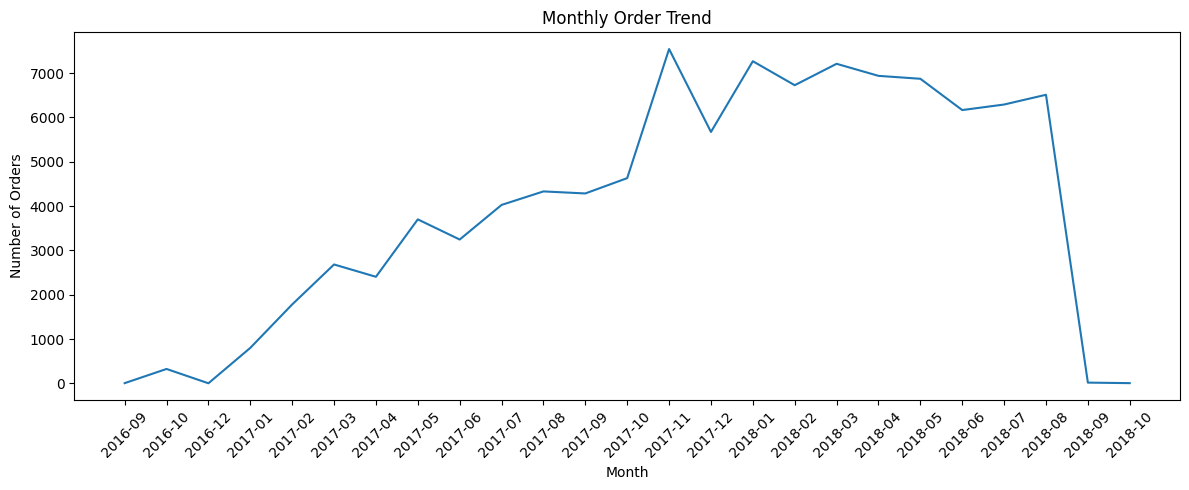

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(monthly_orders["month"].astype(str),
         monthly_orders["orders"])

plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.title("Monthly Order Trend")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [28]:
import sqlite3

conn = sqlite3.connect(":memory:")

orders.to_sql("orders", conn, index=False, if_exists="replace")
customers.to_sql("customers", conn, index=False, if_exists="replace")
products.to_sql("products", conn, index=False, if_exists="replace")
order_items.to_sql("order_items", conn, index=False, if_exists="replace")
reviews.to_sql("reviews", conn, index=False, if_exists="replace")

print("SQL database created successfully!")

ProgrammingError: Error binding parameter 11: type 'Period' is not supported

In [29]:
import sqlite3

conn = sqlite3.connect(":memory:")

# Date columns ko text me convert karo
orders_sql = orders.copy()

for col in [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]:
    orders_sql[col] = orders_sql[col].astype(str)

# Period column ko text me convert karo
orders_sql["month"] = orders_sql["month"].astype(str)

# SQL tables
orders_sql.to_sql("orders", conn, index=False, if_exists="replace")
customers.to_sql("customers", conn, index=False, if_exists="replace")
products.to_sql("products", conn, index=False, if_exists="replace")
order_items.to_sql("order_items", conn, index=False, if_exists="replace")
reviews.to_sql("reviews", conn, index=False, if_exists="replace")

print("SQL database created successfully!")

SQL database created successfully!


In [30]:
query = """
SELECT
    product_id,
    SUM(price) AS revenue
FROM order_items
GROUP BY product_id
ORDER BY revenue DESC
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)

print(result)

                         product_id   revenue
0  bb50f2e236e5eea0100680137654686c  63885.00
1  6cdd53843498f92890544667809f1595  54730.20
2  d6160fb7873f184099d9bc95e30376af  48899.34
3  d1c427060a0f73f6b889a5c7c61f2ac4  47214.51
4  99a4788cb24856965c36a24e339b6058  43025.56
5  3dd2a17168ec895c781a9191c1e95ad7  41082.60
6  25c38557cf793876c5abdd5931f922db  38907.32
7  5f504b3a1c75b73d6151be81eb05bdc9  37733.90
8  53b36df67ebb7c41585e8d54d6772e08  37683.42
9  aca2eb7d00ea1a7b8ebd4e68314663af  37608.90


In [31]:
query = """
WITH customer_orders AS (
    SELECT
        c.customer_unique_id,
        COUNT(o.order_id) AS order_count
    FROM orders o
    JOIN customers c
        ON o.customer_id = c.customer_id
    GROUP BY c.customer_unique_id
)

SELECT
    COUNT(*) AS total_customers,
    SUM(CASE WHEN order_count > 1 THEN 1 ELSE 0 END) AS repeat_customers,
    ROUND(
        100.0 * SUM(CASE WHEN order_count > 1 THEN 1 ELSE 0 END)
        / COUNT(*),
        2
    ) AS repeat_customer_rate
FROM customer_orders;
"""

result = pd.read_sql_query(query, conn)

print(result)

   total_customers  repeat_customers  repeat_customer_rate
0            96096              2997                  3.12


In [32]:
query = """
WITH monthly_orders AS (
    SELECT
        substr(order_purchase_timestamp, 1, 7) AS month,
        COUNT(order_id) AS total_orders
    FROM orders
    GROUP BY month
)

SELECT
    month,
    total_orders,
    RANK() OVER (ORDER BY total_orders DESC) AS order_rank
FROM monthly_orders
ORDER BY order_rank;
"""

result = pd.read_sql_query(query, conn)

print(result.head(10))

     month  total_orders  order_rank
0  2017-11          7544           1
1  2018-01          7269           2
2  2018-03          7211           3
3  2018-04          6939           4
4  2018-05          6873           5
5  2018-02          6728           6
6  2018-08          6512           7
7  2018-07          6292           8
8  2018-06          6167           9
9  2017-12          5673          10


In [33]:
print("Order Value Statistics:")
print(orders["order_value"].describe())

Order Value Statistics:
count    98666.000000
mean       160.577638
std        220.466087
min          9.590000
25%         61.980000
50%        105.290000
75%        176.870000
max      13664.080000
Name: order_value, dtype: float64


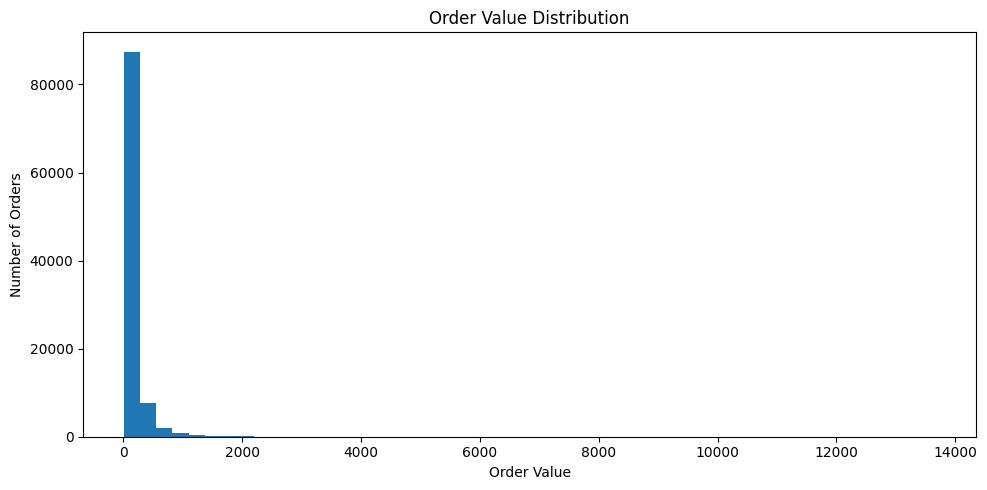

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(orders["order_value"], bins=50)

plt.xlabel("Order Value")
plt.ylabel("Number of Orders")
plt.title("Order Value Distribution")

plt.tight_layout()
plt.show()

In [35]:
shipping_review = orders.merge(
    reviews[["order_id", "review_score"]],
    on="order_id",
    how="inner"
)

print(shipping_review[[
    "delivery_days",
    "review_score"
]].head())

   delivery_days  review_score
0            8.0             4
1           13.0             4
2            9.0             5
3           13.0             5
4            2.0             5


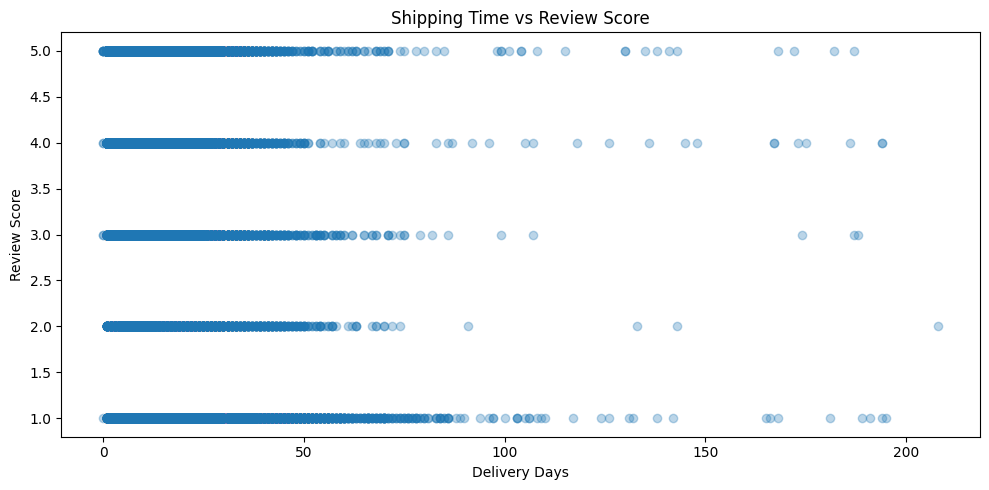

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.scatter(
    shipping_review["delivery_days"],
    shipping_review["review_score"],
    alpha=0.3
)

plt.xlabel("Delivery Days")
plt.ylabel("Review Score")
plt.title("Shipping Time vs Review Score")

plt.tight_layout()
plt.show()

In [37]:
correlation = shipping_review[
    ["delivery_days", "review_score"]
].corr()

print(correlation)

               delivery_days  review_score
delivery_days        1.00000      -0.33366
review_score        -0.33366       1.00000


In [38]:
Q1 = orders["order_value"].quantile(0.25)
Q3 = orders["order_value"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = orders[
    (orders["order_value"] < lower) |
    (orders["order_value"] > upper)
]

print("Lower limit:", lower)
print("Upper limit:", upper)
print("Number of outliers:", len(outliers))

Lower limit: -110.35500000000005
Upper limit: 349.20500000000004
Number of outliers: 7775


In [39]:
print(outliers["order_value"].describe())

count     7775.000000
mean       690.274900
std        500.914983
min        349.400000
25%        409.025000
50%        526.960000
75%        771.980000
max      13664.080000
Name: order_value, dtype: float64


In [40]:
import numpy as np

order_values = orders["order_value"].dropna()

mean = order_values.mean()
std = order_values.std()
n = len(order_values)

standard_error = std / np.sqrt(n)

print("Mean:", mean)
print("Standard deviation:", std)
print("Sample size:", n)
print("Standard error:", standard_error)

Mean: 160.57763809214924
Standard deviation: 220.46608651478383
Sample size: 98666
Standard error: 0.7018721854617629


In [41]:
z = 1.96

lower_ci = mean - z * standard_error
upper_ci = mean + z * standard_error

print("95% Confidence Interval:")
print("Lower:", lower_ci)
print("Upper:", upper_ci)

95% Confidence Interval:
Lower: 159.2019686086442
Upper: 161.9533075756543


In [42]:
orders["day_of_week"] = orders["order_purchase_timestamp"].dt.dayofweek

orders["day_type"] = np.where(
    orders["day_of_week"] >= 5,
    "Weekend",
    "Weekday"
)

print(orders[[
    "order_purchase_timestamp",
    "day_of_week",
    "day_type"
]].head())

  order_purchase_timestamp  day_of_week day_type
0      2017-10-02 10:56:33            0  Weekday
1      2018-07-24 20:41:37            1  Weekday
2      2018-08-08 08:38:49            2  Weekday
3      2017-11-18 19:28:06            5  Weekend
4      2018-02-13 21:18:39            1  Weekday


In [43]:
order_counts = orders["day_type"].value_counts()

print(order_counts)

day_type
Weekday    76594
Weekend    22847
Name: count, dtype: int64


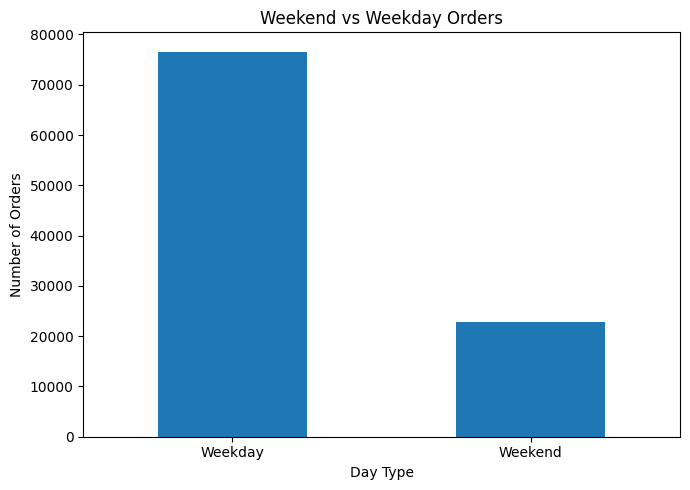

In [44]:
order_counts.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.xlabel("Day Type")
plt.ylabel("Number of Orders")
plt.title("Weekend vs Weekday Orders")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [45]:
summary = pd.DataFrame({
    "Metric": [
        "Average Order Value",
        "Repeat Customer Rate",
        "Shipping-Review Correlation",
        "Weekend Orders",
        "Weekday Orders",
        "Order Value Outliers"
    ],
    "Value": [
        round(mean, 2),
        3.12,
        round(correlation.loc["delivery_days", "review_score"], 2),
        22847,
        76594,
        7775
    ]
})

print(summary)

                        Metric     Value
0          Average Order Value    160.58
1         Repeat Customer Rate      3.12
2  Shipping-Review Correlation     -0.33
3               Weekend Orders  22847.00
4               Weekday Orders  76594.00
5         Order Value Outliers   7775.00


### Finding 1: Low Repeat Customer Rate

The repeat customer rate is only 3.12%, meaning that most customers placed only one order. This suggests that customer retention and repeat purchases may be an important area for improvement.


### Finding 2: Longer Delivery Is Associated With Lower Review Scores

The correlation between delivery time and review score is -0.33. This indicates a moderate negative relationship, meaning that longer delivery times are generally associated with lower customer review scores.

### Finding 3: Order Values Are Right-Skewed

The average order value is ₹160.58, while the median order value is ₹105.29. The higher mean compared with the median indicates a right-skewed distribution, with some high-value orders increasing the average.

### Finding 4: Most Orders Occur on Weekdays

There were 76,594 weekday orders compared with 22,847 weekend orders. This shows that approximately 77% of orders were placed on weekdays, while about 23% were placed on weekends.

### Finding 5: A Few Products Generate High Revenue

The top product generated ₹63,885 in product revenue. The top 10 products include categories such as health_beauty, computers, computers_accessories, baby, cool_stuff, watches_gifts, and furniture_decor. This indicates that some products contribute significantly to overall sales revenue.

## Business Recommendation

The company should focus on improving customer retention and delivery performance. Since the repeat customer rate is only 3.12% and longer delivery times are associated with lower review scores, the business can introduce targeted offers for existing customers and improve delivery speed. The company should also monitor high-value products and ensure their availability because a small number of products generate significant revenue.

# Final Project Report

## E-Commerce Health Check

### Key Findings

1. **Low Repeat Customer Rate:** The repeat customer rate is only 3.12%, indicating that most customers placed only one order.

2. **Delivery Time and Customer Satisfaction:** The correlation between delivery time and review score is -0.33, indicating that longer delivery times are generally associated with lower review scores.

3. **Right-Skewed Order Values:** The average order value is ₹160.58, while the median is ₹105.29. This indicates that some high-value orders increase the average.

4. **Weekday Orders Dominate:** There were 76,594 weekday orders compared with 22,847 weekend orders, meaning approximately 77% of orders occurred on weekdays.

5. **High-Revenue Products:** The top product generated ₹63,885 in product revenue, showing that some products contribute significantly to sales revenue.

### Business Recommendation

The company should focus on improving customer retention and delivery performance. Since the repeat customer rate is only 3.12% and longer delivery times are associated with lower review scores, the business can introduce targeted offers for existing customers and improve delivery speed. The company should also monitor high-value products and ensure their availability because a small number of products generate significant revenue.

## Project Overview

This project performs an E-Commerce Health Check using the Olist Brazilian E-Commerce Public Dataset. The analysis focuses on customer behavior, product revenue, order-value patterns, delivery performance, customer satisfaction, and order trends.

Python, Pandas, NumPy, SQL, and Matplotlib were used to clean, analyze, and visualize the data.

## Methodology

The dataset was loaded into Python using Pandas. The data was inspected for missing values and duplicates, and date columns were converted into datetime format.

Multiple datasets were merged using common identifiers such as order_id, customer_id, and product_id. Order values were calculated using product price and freight value.

SQL was used to analyze top products by revenue, repeat customer rate, and monthly order trends. CTEs, JOINs, GROUP BY, and a window function were used in the SQL analysis.

Exploratory Data Analysis was performed using descriptive statistics and visualizations. The relationship between delivery time and review score was analyzed using correlation. IQR was used for outlier detection, and a 95% confidence interval was calculated for the average order value.

## Key Results

- The average order value was **₹160.58**, with a median order value of **₹105.29**.
- The 95% confidence interval for the average order value was approximately **₹159.20 to ₹161.95**.
- The repeat customer rate was **3.12%**.
- The correlation between delivery time and review score was **-0.33**.
- There were **76,594 weekday orders** and **22,847 weekend orders**.
- The IQR method identified **7,775 order-value outliers**.
- The highest-revenue product generated **₹63,885** in product revenue.

## Conclusion

The E-Commerce Health Check shows that the dataset contains a large number of weekday orders, a low repeat customer rate, and a right-skewed order-value distribution. The analysis also found a negative relationship between delivery time and review score.

These findings can help the business focus on customer retention, delivery performance, and monitoring high-revenue products.